In [2]:
import os
print(os.getcwd())
import sys
sys.path.append("QuAlgorithms")
sys.path.append(".")
print(sys.path)
import numpy as np

from state_preparation import matrix_msob2
from qsiht_library import generate_binary_values
from qsiht_library import generate_and_shift_array
from qsiht_library import generalFastPath
from qft import qft
from qft import qft2
import qiskit 
from qiskit import QuantumCircuit
import numpy as np
import math
from medmnist import BreastMNIST



c:\Users\mando\Downloads\QuAlgorithms\QuAlgorithms-master\qu_algorithms
['c:\\Users\\mando\\miniconda3\\envs\\qiskit\\python314.zip', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\DLLs', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit', '', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\win32', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\mando\\miniconda3\\envs\\qiskit\\Lib\\site-packages\\Pythonwin', 'QuAlgorithms', '.']


In [3]:
import math
import numpy as np
from qiskit import QuantumCircuit


# ============================================================
# CORE BUTTERFLY
# ============================================================

def butterfly(values):
    values = [float(v) for v in values]
    n = len(values)

    if n < 2:
        raise ValueError("Need at least 2 values.")
    if (n & (n - 1)) != 0:
        raise ValueError(f"Length must be a power of 2. Got {n}.")

    stages = []
    current = values[:]

    while len(current) > 1:
        pairs = []
        next_values = []

        for i in range(0, len(current), 2):
            j, k = current[i], current[i + 1]

            # ✅ FIXED
            angle_rad = -2 * math.atan2(k, j)

            new_val = math.sqrt(j**2 + k**2)

            pairs.append({
                "j": j,
                "k": k,
                "angle_rad": angle_rad,
                "newvalue": new_val
            })

            next_values.append(new_val)

        stages.append(pairs)
        current = next_values

    return {"stages": stages, "final": current[0]}





# ============================================================
# POSTORDER
# ============================================================

def butterfly_postorder_nodes(stages):
    """
    Returns nodes in postorder:
    left subtree, right subtree, parent

    Also returns stage/pair info so we know where each angle came from.
    """
    def walk(stage_idx, pair_idx):
        node = {
            "stage": stage_idx + 1,
            "pair": pair_idx,
            "angle_rad": stages[stage_idx][pair_idx]["angle_rad"]
        }

        if stage_idx == 0:
            return [node]

        left = walk(stage_idx - 1, 2 * pair_idx)
        right = walk(stage_idx - 1, 2 * pair_idx + 1)
        return left + right + [node]

    return walk(len(stages) - 1, 0)


# ============================================================
# BIT / QUBIT MAPPING
# Convention B:
#   binary b_(n-1)...b_1 b_0
#   LSB (b_0) is bottom wire
#   MSB (b_(n-1)) is top wire
# In Qiskit:
#   q_0 is top, q_(n-1) is bottom
# so bit_pos -> qiskit qubit index = nbits - 1 - bit_pos
# ============================================================

def bit_to_qubit(bit_pos, nbits):
    #return nbits - 1 - bit_pos
    return bit_pos



# ============================================================
# CONTROLLED RY WITH MIXED 0/1 CONTROLS
# ============================================================

def apply_conditioned_ry(qc, theta, target, controls):
    """
    Apply Ry(theta) on `target`, conditioned on controls.

    controls = list of (qubit_index, required_bit)
      required_bit = 0 or 1

    Qiskit directly controls on |1>, so for control-on-0 we do:
      X -- control -- X
    """
    zero_controls = [q for q, bit in controls if bit == 0]
    one_controls = [q for q, bit in controls if bit == 1]
    control_qubits = [q for q, _ in controls]

    # Turn 0-controls into 1-controls temporarily
    for q in zero_controls:
        qc.x(q)

    if len(control_qubits) == 0:
        qc.ry(theta, target)
    elif len(control_qubits) == 1:
        qc.cry(theta, control_qubits[0], target)
    else:
        qc.mcry(theta, control_qubits, target, None, mode='noancilla')

    # Undo the temporary X gates
    for q in reversed(zero_controls):
        qc.x(q)


# ============================================================
# MAP A BUTTERFLY NODE TO THE BASIS-STATE PAIR IT REPRESENTS
# ============================================================

def node_to_basis_pair(stage, pair, nbits):
    """
    stage is 1-based:
      stage 1 differs in bit 0
      stage 2 differs in bit 1
      ...
      stage s differs in bit s-1

    For a given stage/pair, the represented pair is:

      base = pair * 2^stage
      indices = base and base + 2^(stage-1)

    Example, nbits=2:
      stage=1, pair=0 -> 00 and 01
      stage=1, pair=1 -> 10 and 11
      stage=2, pair=0 -> 00..01 vs 10..11 -> differs in bit 1
    """
    diff_bit = stage - 1
    base = pair * (2 ** stage)
    a = base
    b = base + (2 ** diff_bit)
    return a, b, diff_bit


def controls_for_pair(a, b, diff_bit, nbits):
    """
    Build control conditions from the bits that stay the same.

    Returns:
      target_qubit, controls

    controls is list of (qubit_index, required_bit)
    """
    target_qubit = bit_to_qubit(diff_bit, nbits)
    controls = []

    for bit_pos in range(nbits):
        if bit_pos == diff_bit:
            continue

        bit_val_a = (a >> bit_pos) & 1
        bit_val_b = (b >> bit_pos) & 1

        if bit_val_a != bit_val_b:
            raise ValueError("Control bits must match for all non-differing positions.")

        controls.append((bit_to_qubit(bit_pos, nbits), bit_val_a))

    # Sort controls top-to-bottom for prettier circuits
    controls.sort(key=lambda x: x[0])
    return target_qubit, controls


# ============================================================
# BUILD THE QUANTUM CIRCUIT
# ============================================================

def butterfly_quantum_circuit(values):
    result = butterfly(values)
    stages = result["stages"]
    ordered_nodes = butterfly_postorder_nodes(stages)

    n = len(values)
    nbits = int(math.log2(n))
    qc = QuantumCircuit(nbits)

    for node in ordered_nodes:
        stage = node["stage"]
        pair = node["pair"]
        theta = node["angle_rad"]

        a, b, diff_bit = node_to_basis_pair(stage, pair ) #"nbits"
        target, controls = controls_for_pair(a, b, diff_bit, nbits)

        apply_conditioned_ry(qc, theta, target, controls)

        print(
            f"stage={stage}, pair={pair+1}, "
            f"basis pair=({a:0{nbits}b}, {b:0{nbits}b}), "
            f"target bit={diff_bit}, target q={target}, controls={controls}"
        )

    return qc, result


# ============================================================
# EXAMPLE 1: 2x2 IMAGE -> 4 VALUES -> 2 QUBITS
# ============================================================

#z = np.array([[12, 35],
    #          [90, 17]], dtype=float)

#values = z.flatten()

#qc, result = butterfly_quantum_circuit(values)

#print("\nFinal:", result["final"])
#print(qc.draw())

In [4]:
# ============================================================
#  HELPER
# ============================================================
""""""
def _trim_to_power2(values):
    p = 1
    while p <= len(values):
        p <<= 1
    p >>= 1
    if p < 2:
        raise ValueError("Not enough values (need at least 2).")
    return [float(v) for v in values[:p]]







# ============================================================
#  PRINTER
# ============================================================

def print_result(result, values, max_stages_full=4):
    print("\n" + "=" * 60)
    print(f"  BUTTERFLY  —  {len(values)} input values  |  {len(result['stages'])} stages")
    print("=" * 60)

    for si, stage in enumerate(result["stages"]):
        print(f"\n  STAGE {si + 1}  ({len(stage)} pair{'s' if len(stage) > 1 else ''})")
        print("  " + "-" * 50)
        show = stage if si < max_stages_full else (stage[:4] + [None] + stage[-4:])
        for item in show:
            if item is None:
                print("  ...")
                continue
            sign = "+" if item["angle"] >= 0 else ""
            print(f"  j={item['j']:10.4f}  k={item['k']:10.4f}  |  "
                  f"angle={sign}{item['angle']:8.4f}°  →  {item['new_val']:.4f}")

    print("\n" + "=" * 60)
    print(f"  FINAL VALUE : {result['final']:.6f}")
    print("=" * 60)

    print("\n  ANGLE SUMMARY")
    print("  " + "-" * 50)
    for si, stage in enumerate(result["stages"]):
        angles = [f"{'+' if p['angle'] >= 0 else ''}{p['angle']:.2f}°" for p in stage]
        preview = ",  ".join(angles) if len(angles) <= 8 else ",  ".join(angles[:4]) + "  ...  " + ",  ".join(angles[-4:])
        print(f"  Stage {si + 1}: {preview}")
    print()



In [5]:
import math
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate


# ============================================================
# 1) Butterfly reduction
# ============================================================
""""
def butterfly(values):
    values = [float(v) for v in values]
    n = len(values)

    if n < 2:
        raise ValueError("Need at least 2 values.")
    if (n & (n - 1)) != 0:
        raise ValueError(f"Length must be a power of 2. Got {n}.")

    stages = []
    current = values[:]

    while len(current) > 1:
        pairs = []
        next_values = []

        for i in range(0, len(current), 2):
            j, k = current[i], current[i + 1]

            #angle_rad = -math.atan(k/ j)
            
            if j ==0:
                if k > 0:
                    angle = -math.pi / 2
                else:
                     angle = math.pi / 2
            else:
                angle_rad = -2*math.atan(k / j)
            
            new_val = math.sqrt(j**2 + k**2)

            pairs.append({
                "j": j,
                "k": k,
                "angle_rad": angle_rad,
                "newvalue": new_val
            })
            next_values.append(new_val)

        stages.append(pairs)
        current = next_values

    return {"stages": stages, "final": current[0]} """




# ============================================================
# 2) Postorder traversal
#    For 8 inputs this gives:
#    a1, a2, b1, a3, a4, b2, c1
# ============================================================

def butterfly_postorder_nodes(stages):
    def walk(stage_idx, pair_idx):
        node = {
            "stage": stage_idx + 1,      # 1-based
            "pair": pair_idx,            # 0-based
            "angle_rad": stages[stage_idx][pair_idx]["angle_rad"]
        }

        if stage_idx == 0:
            return [node]

        left = walk(stage_idx - 1, 2 * pair_idx)
        right = walk(stage_idx - 1, 2 * pair_idx + 1)
        return left + right + [node]

    return walk(len(stages) - 1, 0)


# ============================================================
# 3) Convention B bit -> qubit map
#    binary: b_(n-1) ... b_1 b_0
#    LSB b_0 is bottom wire
#    In Qiskit: q_0 top, q_(n-1) bottom
# ============================================================

def bit_to_qubit(bit_pos, nbits):
    #return nbits - 1 - bit_pos
    return bit_pos


# ============================================================
# #4) From butterfly node -> represented basis pair
#
# stage 1 differs in bit 0
# stage 2 differs in bit 1
# ...
#
# base = pair * 2^stage
# a = base
# b = base + 2^(stage-1)
# ============================================================

def node_to_basis_pair(stage, pair):
    diff_bit = stage - 1
    base = pair * (2 ** stage)
    a = base
    b = base + (2 ** diff_bit)
    return a, b, diff_bit


# ============================================================
# 5) Build target/control info
#    ctrl_state is written in the same order as the control
#    qubits are passed to qc.append(...)
# ============================================================

def controls_for_pair(a, b, diff_bit, nbits):
    target_qubit = bit_to_qubit(diff_bit, nbits)
    controls = []

    for bit_pos in range(nbits - 1, -1, -1):
        if bit_pos == diff_bit:
            continue

        abit = (a >> bit_pos) & 1
        bbit = (b >> bit_pos) & 1

        if abit != bbit:
            raise ValueError("Non-target bits must match.")

        qubit = bit_to_qubit(bit_pos, nbits)
        controls.append((qubit, abit))

    return target_qubit, controls


# ============================================================
# 6) Build the full multi-controlled-Ry butterfly circuit
# ============================================================

def build_butterfly_mc_ry_circuit(values, add_labels=True):
    result = butterfly(values)
    stages = result["stages"]
    ordered_nodes = butterfly_postorder_nodes(stages)

    n = len(values)
    nbits = int(math.log2(n))
    qc = QuantumCircuit(nbits)

    gate_info = []

    for idx, node in enumerate(ordered_nodes, start=1):
        stage = node["stage"]
        pair = node["pair"]
        theta = node["angle_rad"]

        a, b, diff_bit = node_to_basis_pair(stage, pair)
        target, controls = controls_for_pair(a, b, diff_bit, nbits)

        # Keep qubits and bits aligned
        control_qubits = [q for q, bit in controls]
        control_bits = [bit for q, bit in controls]

        # Try reversed order for Qiskit ctrl_state convention
        control_qubits = [q for q, bit in controls]
        control_bits   = [bit for q, bit in controls]

        # FIX: reverse for Qiskit ordering
        ctrl_state = ''.join(str(bit) for bit in reversed(control_bits))

        label = f"s{stage}p{pair+1}" if add_labels else None

        if len(control_qubits) == 0:
            qc.ry(theta, target)
        else:
            gate = RYGate(theta, label=label).control(
                num_ctrl_qubits=len(control_qubits),
                ctrl_state=ctrl_state
            )
            qc.append(gate, control_qubits + [target])

        gate_info.append({
            "order": idx,
            "stage": stage,
            "pair": pair + 1,
            "basis_pair": (f"{a:0{nbits}b}", f"{b:0{nbits}b}"),
            "target_bit": diff_bit,
            "target_qubit": target,
            "controls": controls,
            "ctrl_state": ctrl_state if control_qubits else "(none)",
            "angle_rad": theta,
            "angle_deg": math.degrees(theta),
        })

    return qc, result, gate_info


# ============================================================
# 7) Pretty print helper
# ============================================================

def print_gate_info(gate_info):
    for g in gate_info:
        print(
            f"{g['order']:>2}. "
            f"stage={g['stage']} pair={g['pair']} "
            f"basis={g['basis_pair'][0]} <-> {g['basis_pair'][1]} "
            f"target_bit={g['target_bit']} target_q={g['target_qubit']} "
            f"ctrl_state={g['ctrl_state']} controls={g['controls']} "
            f"angle={g['angle_deg']:.4f}°"
        )


# ============================================================
# 8) Example
# ============================================================

"""values = np.random.randint(0, 256, size=(64,), dtype=np.uint8).tolist()

result = butterfly(values)
qc, result, gate_info = build_butterfly_mc_ry_circuit(values)

print_gate_info(gate_info)
print("\nFinal:", result["final"])
print(qc.draw()) """

'values = np.random.randint(0, 256, size=(64,), dtype=np.uint8).tolist()\n\nresult = butterfly(values)\nqc, result, gate_info = build_butterfly_mc_ry_circuit(values)\n\nprint_gate_info(gate_info)\nprint("\nFinal:", result["final"])\nprint(qc.draw()) '

Image tensor shape: torch.Size([1, 32, 32])
Label: [7]
Min pixel: 0.24705882370471954
Max pixel: 0.9450980424880981


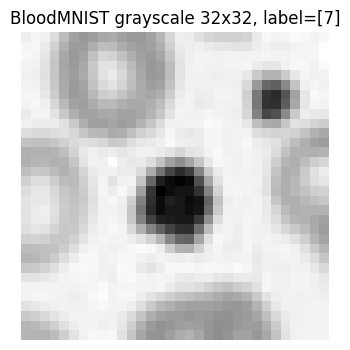

Vector length: 1024
Vector norm: 1.0000000000000002


In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import medmnist
from medmnist import INFO
import matplotlib.pyplot as plt

data_flag = 'bloodmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.Grayscale(),      # RGB -> 1 channel
    transforms.Resize((32, 32)), # now actually 32x32
    transforms.ToTensor(),       # shape: [1, 32, 32]
])

train_dataset = DataClass(split='train', transform=transform, download=True)
val_dataset   = DataClass(split='val', transform=transform, download=True)
test_dataset  = DataClass(split='test', transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

def image_to_quantum_vector(img_tensor):
    # img_tensor expected shape: [1, 32, 32]
    vec = img_tensor.squeeze(0).numpy().astype(np.float64).flatten()
    norm = np.linalg.norm(vec)
    if norm == 0:
        vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
    else:
        vec = vec / norm
    return vec

img, label = train_dataset[0]

print("Image tensor shape:", img.shape)   # should be torch.Size([1, 32, 32])
print("Label:", label)
print("Min pixel:", img.min().item())
print("Max pixel:", img.max().item())

plt.figure(figsize=(4, 4))
plt.imshow(img.squeeze(0).numpy(), cmap="gray", interpolation="nearest")
plt.title(f"BloodMNIST grayscale 32x32, label={label}")
plt.axis("off")
plt.show()

vec = image_to_quantum_vector(img)
print("Vector length:", len(vec))         # should be 1024
print("Vector norm:", np.linalg.norm(vec)) # should be ~1.0

In [7]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np

# get one image from your dataset
img, label = train_dataset[0]

# convert image -> normalized vector
vec = image_to_quantum_vector(img)

print("Vector length:", len(vec))
print("Norm:", np.linalg.norm(vec))

# build your butterfly state-prep circuit
qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

#print("=== State-preparation circuit ===")
#print(qc.draw())

# inverse circuit
qc_inv = qc.inverse()

##print("\n=== Inverse circuit ===")
##print(qc_inv.draw())

# -------------------------------------------------
# Verify the prepared state
# -------------------------------------------------
sv_prepared = Statevector.from_instruction(qc)

##print("\nPrepared state dimension:", len(sv_prepared.data))
##print("Prepared-state norm:", np.linalg.norm(sv_prepared.data))

# optional: compare to input vector
# depending on qubit ordering convention, this may or may not match exactly
##print("Direct match to vec:", np.allclose(sv_prepared.data, vec, atol=1e-8))

# -------------------------------------------------
# Verify inverse undoes the preparation
# -------------------------------------------------
full_check = QuantumCircuit(qc.num_qubits)
full_check.compose(qc, inplace=True)
full_check.compose(qc_inv, inplace=True)

sv_back = Statevector.from_instruction(full_check)

zero_state = np.zeros(2**qc.num_qubits, dtype=complex)
zero_state[0] = 1.0

##print("Returns to |0...0>:", np.allclose(sv_back.data, zero_state, atol=1e-8))

Vector length: 1024
Norm: 1.0000000000000002


In [8]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
import numpy as np

#2d qft method 

def build_2d_qft_circuit_after_prep(prep_circuit, n_row_qubits, n_col_qubits, do_swaps=True):
    """
    Apply a separable 2D QFT after a state-preparation circuit.

    Assumptions:
      - prep_circuit prepares the image state
      - first n_row_qubits are row qubits
      - last  n_col_qubits are column qubits
    """
    n = prep_circuit.num_qubits
    assert n == n_row_qubits + n_col_qubits, "row+col qubits must equal total qubits"

    qc_out = QuantumCircuit(n)
    qc_out.compose(prep_circuit, inplace=True)

    row_qubits = list(range(n_row_qubits))
    col_qubits = list(range(n_row_qubits, n))

    qft_rows = QFT(num_qubits=n_row_qubits, do_swaps=do_swaps)
    qft_cols = QFT(num_qubits=n_col_qubits, do_swaps=do_swaps)

    qc_out.compose(qft_rows, qubits=row_qubits, inplace=True)
    qc_out.compose(qft_cols, qubits=col_qubits, inplace=True)

    return qc_out

# Example
n = qc_inv.num_qubits
n_row_qubits = n // 2
n_col_qubits = n - n_row_qubits

qc_2d_qft = build_2d_qft_circuit_after_prep(
    qc_inv,
    n_row_qubits,
    n_col_qubits,
    do_swaps=True   # easiest if you want standard QFT ordering
)

###print(qc_2d_qft.draw())

sv = Statevector.from_instruction(qc_2d_qft)
##print("Norm:", np.linalg.norm(sv.data))

C:\Users\mando\AppData\Local\Temp\ipykernel_83912\2248475221.py:26: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_rows = QFT(num_qubits=n_row_qubits, do_swaps=do_swaps)
C:\Users\mando\AppData\Local\Temp\ipykernel_83912\2248475221.py:27: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_cols = QFT(num_qubits=n_col_qubits, do_swaps=do_swaps)


Vector length: 1024
Vector norm: 1.0000000000000002
Prep-state norm: 0.9999999999891862
Prep matches vec: True

=== 2D QFT circuit ===


C:\Users\mando\AppData\Local\Temp\ipykernel_83912\1405145218.py:54: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_2d_qft.compose(QFT(n_row, do_swaps=True), qubits=row_qubits, inplace=True)
C:\Users\mando\AppData\Local\Temp\ipykernel_83912\1405145218.py:55: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_2d_qft.compose(QFT(n_col, do_swaps=True), qubits=col_qubits, inplace=True)


                                                                         »
q_0: ──────o─────────────o─────────────o────────────o────────────o───────»
           │             │             │            │            │       »
q_1: ──────o─────────────o─────────────o────────────o────────────o───────»
           │             │             │            │            │       »
q_2: ──────o─────────────o─────────────o────────────o────────────o───────»
           │             │             │            │            │       »
q_3: ──────o─────────────o─────────────o────────────o────────────o───────»
           │             │             │            │            │       »
q_4: ──────o─────────────o─────────────o────────────o────────────o───────»
           │             │             │            │      ┌─────┴──────┐»
q_5: ──────o─────────────o─────────────o────────────o──────┤ Ry(1.5655) ├»
           │             │             │       ┌────┴─────┐└─────┬──────┘»
q_6: ──────o─────────────

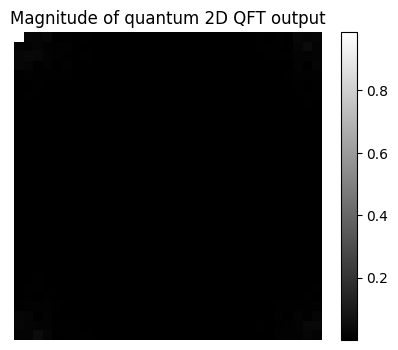

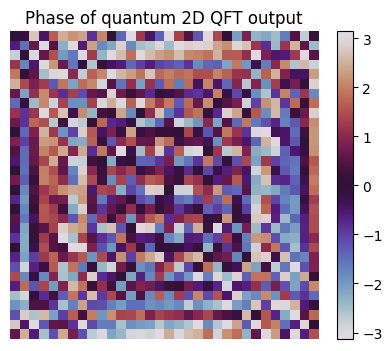


=== Comparison with classical 2D FFT ===
All close: False
Max abs error: 0.05114540698896995
Mean abs error: 0.0021944524227512415


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector

# -------------------------------------------------
# 1) Your image -> normalized quantum vector
# -------------------------------------------------
def image_to_quantum_vector(img_tensor):
    vec = img_tensor.squeeze(0).numpy().astype(np.float64).flatten()
    norm = np.linalg.norm(vec)
    if norm == 0:
        vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
    else:
        vec = vec / norm
    return vec

img, label = train_dataset[0]
vec = image_to_quantum_vector(img)

print("Vector length:", len(vec))          # 1024
print("Vector norm:", np.linalg.norm(vec)) # ~1

# -------------------------------------------------
# 2) Build your prep circuit
#    IMPORTANT: you said qc_inv prepares your image state
# -------------------------------------------------
qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)
qc_inv = qc.inverse()

# Verify that qc_inv really prepares the image state in your convention
sv_prep = Statevector.from_instruction(qc_inv)
print("Prep-state norm:", np.linalg.norm(sv_prep.data))
print("Prep matches vec:", np.allclose(sv_prep.data, vec, atol=1e-8))

# -------------------------------------------------
# 3) Build 2D QFT circuit
#    32x32 => 5 row qubits + 5 col qubits
# -------------------------------------------------
n_row = 5
n_col = 5
n = n_row + n_col

assert qc_inv.num_qubits == 10, f"Expected 10 qubits for 32x32 image, got {qc_inv.num_qubits}"

row_qubits = list(range(n_row))
col_qubits = list(range(n_row, n))

qc_2d_qft = QuantumCircuit(n)
qc_2d_qft.compose(qc_inv, inplace=True)

# Use do_swaps=True so the output ordering is the standard QFT ordering
qc_2d_qft.compose(QFT(n_row, do_swaps=True), qubits=row_qubits, inplace=True)
qc_2d_qft.compose(QFT(n_col, do_swaps=True), qubits=col_qubits, inplace=True)

print("\n=== 2D QFT circuit ===")
print(qc_2d_qft.draw())

# -------------------------------------------------
# 4) Get state after 2D QFT
# -------------------------------------------------
sv_after_qft = Statevector.from_instruction(qc_2d_qft)
state_after_qft = sv_after_qft.data

print("\nState dimension after QFT:", len(state_after_qft))
print("State norm after QFT:", np.linalg.norm(state_after_qft))

# Reshape back into 32x32 complex array
qft_2d_quantum = state_after_qft.reshape(32, 32)

# Print a small corner of the complex matrix
print("\nTop-left 4x4 block of quantum 2D QFT result:")
print(qft_2d_quantum[:4, :4])

# -------------------------------------------------
# 5) Plot what "the thing after QFT" looks like
# -------------------------------------------------
magnitude = np.abs(qft_2d_quantum)
phase = np.angle(qft_2d_quantum)

plt.figure(figsize=(5, 4))
plt.imshow(magnitude, cmap="gray")
plt.title("Magnitude of quantum 2D QFT output")
plt.colorbar()
plt.axis("off")
plt.show()

plt.figure(figsize=(5, 4))
plt.imshow(phase, cmap="twilight")
plt.title("Phase of quantum 2D QFT output")
plt.colorbar()
plt.axis("off")
plt.show()

# -------------------------------------------------
# 6) Classical reference: 2D FFT with orthonormal normalization
# -------------------------------------------------
img_2d = vec.reshape(32, 32)
qft_2d_classical = np.fft.fft2(img_2d, norm="ortho")

# -------------------------------------------------
# 7) Compare quantum result vs classical result
#    Remove global phase before comparison
# -------------------------------------------------
q = qft_2d_quantum.flatten()
c = qft_2d_classical.flatten()

# Find a stable reference entry for global phase
idx = np.argmax(np.abs(c))
if np.abs(c[idx]) > 1e-12:
    global_phase = q[idx] / c[idx]
else:
    global_phase = 1.0 + 0.0j

q_aligned = q / global_phase

max_err = np.max(np.abs(q_aligned - c))
mean_err = np.mean(np.abs(q_aligned - c))
is_close = np.allclose(q_aligned, c, atol=1e-6)

print("\n=== Comparison with classical 2D FFT ===")
print("All close:", is_close)
print("Max abs error:", max_err)
print("Mean abs error:", mean_err)

In [10]:
####fidelity of the inverse preparation state method 
from qiskit.quantum_info import Statevector, state_fidelity
import numpy as np

img, label = train_dataset[0]
vec = image_to_quantum_vector(img)

qc, result, gate_info = build_butterfly_mc_ry_circuit(vec)

# test forward
#sv_forward = Statevector.from_instruction(qc)
#fid_forward = state_fidelity(sv_forward, vec)

# test inverse
qc_inv = qc.inverse()
sv_inverse = Statevector.from_instruction(qc_inv)
fid_inverse = state_fidelity(sv_inverse, vec)

#print("Forward fidelity:", fid_forward)
print("Inverse fidelity:", fid_inverse)

Inverse fidelity: 0.9999999999783733


Positive class index: 6
Positive class name : neutrophil
Image side          : 32
joblib available    : True
Parallel requested  : True
Train: total=800, positives=155, negatives=645
Val: total=400, positives=81, negatives=319
Test: total=400, positives=75, negatives=325

Butterfly prep fidelity on first 32x32 sample: 0.9999999999783462
=== Quantum SPSA training ===
Image side           : 32
Qubits               : 10
Layers               : 1
Circuit params       : 30
Readout qubits       : 4
Total params         : 35
Train samples        : 800
Val samples          : 400
Epochs               : 20
Batch size           : 64
Positive class idx   : 6
Positive class name  : neutrophil
Class weights        : {'pos_weight': 2.5806451612903225, 'neg_weight': 0.6201550387596899}
Parallel enabled     : True
Epoch 01/20 | train_loss=0.6933 val_loss=0.7047 | train_acc=0.1938 val_acc=0.2025 | train_auc=0.4722 val_auc=0.5492
Epoch 02/20 | train_loss=0.6932 val_loss=0.7047 | train_acc=0.1938 val_acc=0

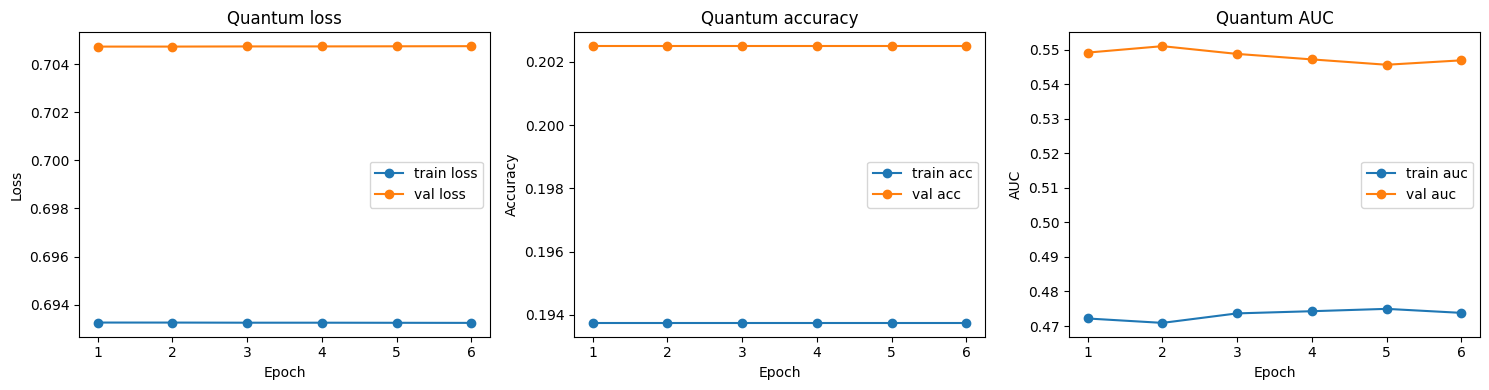


=== Quantum model results ===

Train loss: 0.693251
Train acc : 0.193750
Train auc : 0.472178
Train confusion matrix:
[[  0 645]
 [  0 155]]

Val loss: 0.704737
Val acc : 0.202500
Val auc : 0.549170
Val confusion matrix:
[[  0 319]
 [  0  81]]

Test loss: 0.685037
Test acc : 0.187500
Test auc : 0.448369
Test confusion matrix:
[[  0 325]
 [  0  75]]

Example TEST predictions:
Sample 00: raw_label=3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)), binary_true=0, prob=0.5070, pred=1
Sample 01: raw_label=0 (basophil), binary_true=0, prob=0.5063, pred=1
Sample 02: raw_label=1 (eosinophil), binary_true=0, prob=0.5065, pred=1
Sample 03: raw_label=3 (immature granulocytes(myelocytes, metamyelocytes and promyelocytes)), binary_true=0, prob=0.5066, pred=1
Sample 04: raw_label=1 (eosinophil), binary_true=0, prob=0.5064, pred=1
Sample 05: raw_label=1 (eosinophil), binary_true=0, prob=0.5066, pred=1
Sample 06: raw_label=3 (immature granulocytes(myelocytes, metamyelocytes and 

In [ ]:
import os
import math
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, roc_auc_score

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, state_fidelity

# Optional parallel backend
try:
    from joblib import Parallel, delayed
    JOBLIB_AVAILABLE = True
except Exception:
    JOBLIB_AVAILABLE = False


# ============================================================
# CONFIG
# ============================================================

# BloodMNIST is multi-class. This block uses one-vs-rest binary training.
# Change this if you want a different positive class.
POSITIVE_CLASS = 6

# Full 32x32 amplitude encoding -> 1024 amplitudes -> 10 qubits
IMAGE_SIDE = 32

# Sample budgets
TRAIN_SAMPLES = 800
VAL_SAMPLES   = 400
TEST_SAMPLES  = 400

# Variational circuit
N_LAYERS = 2
READOUT_QUBITS = 1   # use <Z> on the first few qubits as features

# SPSA optimizer
EPOCHS = 50
BATCH_SIZE = 64
SEED = 42

SPSA_A = 0.08
SPSA_C = 0.12
SPSA_ALPHA = 0.602
SPSA_GAMMA = 0.101

# Regularization / training behavior
L2_REG = 1e-4
USE_CLASS_WEIGHTS = True
EARLY_STOPPING_PATIENCE = 10

# Parallelism
USE_PARALLEL = True
N_JOBS = int(os.environ.get("QML_N_JOBS", "-1"))  # -1 = all cores if joblib is available
PARALLEL_MIN_SAMPLES = 32

# Diagnostics
DO_BUTTERFLY_SANITY_CHECK = True
PRINT_EVERY = 1


# ============================================================
# LABEL / DATA HELPERS
# ============================================================

def class_name_from_info(class_idx):
    try:
        return info["label"][str(class_idx)]
    except Exception:
        return str(class_idx)

def extract_scalar_label(label):
    """
    Convert MedMNIST label to Python int.
    """
    if hasattr(label, "numpy"):
        return int(np.squeeze(label.numpy()))
    return int(np.squeeze(label))

def make_binary_target(label, positive_class=POSITIVE_CLASS):
    """
    One-vs-rest binary target for BloodMNIST.
    """
    y = extract_scalar_label(label)
    return 1 if y == positive_class else 0

def build_cached_dataset(dataset, max_samples, positive_class=POSITIVE_CLASS):
    """
    Cache normalized 32x32 amplitude vectors and labels.

    Uses your existing image_to_quantum_vector(img), which should already
    produce a normalized vector of length 1024 from the 32x32 image.
    """
    cached = []
    total = min(max_samples, len(dataset))

    for i in range(total):
        img, label = dataset[i]

        vec = image_to_quantum_vector(img)
        vec = np.asarray(vec, dtype=np.float64)

        if len(vec) != IMAGE_SIDE * IMAGE_SIDE:
            raise ValueError(
                f"Expected vector length {IMAGE_SIDE * IMAGE_SIDE}, got {len(vec)}. "
                f"Check your image preprocessing."
            )

        # Safety renormalization
        norm = np.linalg.norm(vec)
        if norm == 0:
            vec = np.ones_like(vec, dtype=np.float64) / np.sqrt(len(vec))
        else:
            vec = vec / norm

        y_bin = make_binary_target(label, positive_class=positive_class)
        y_raw = extract_scalar_label(label)

        cached.append({
            "index": i,
            "vec": vec,
            "y": y_bin,
            "raw_label": y_raw,
        })

    return cached

def summarize_cached_dataset(name, cached):
    ys = np.array([item["y"] for item in cached], dtype=int)
    pos = int(np.sum(ys == 1))
    neg = int(np.sum(ys == 0))
    print(f"{name}: total={len(cached)}, positives={pos}, negatives={neg}")

def compute_class_weights(cached):
    ys = np.array([item["y"] for item in cached], dtype=int)
    n_pos = max(1, int(np.sum(ys == 1)))
    n_neg = max(1, int(np.sum(ys == 0)))
    total = len(ys)

    # Balanced weights
    pos_weight = total / (2.0 * n_pos)
    neg_weight = total / (2.0 * n_neg)
    return float(pos_weight), float(neg_weight)


# ============================================================
# OPTIONAL BUTTERFLY SANITY CHECK
# ============================================================

def butterfly_prep_fidelity_for_sample(vec):
    """
    Check whether your butterfly inverse still prepares the sample vector.
    This is only for sanity checking, not for the main training loop.
    """
    qc_raw, _, _ = build_butterfly_mc_ry_circuit(vec)
    qc_prep = qc_raw.inverse()
    sv = Statevector.from_instruction(qc_prep)
    return float(state_fidelity(sv, vec))


# ============================================================
# VARIATIONAL CIRCUIT
# ============================================================

def add_ring_variational_layer(qc, theta_circuit, n_qubits, layer_idx):
    """
    One trainable ring layer:
      RY on all qubits
      RZ on all qubits
      RX on all qubits
      ring of CX gates
    """
    base = layer_idx * (3 * n_qubits)

    for q in range(n_qubits):
        qc.ry(theta_circuit[base + q], q)

    for q in range(n_qubits):
        qc.rz(theta_circuit[base + n_qubits + q], q)

    for q in range(n_qubits):
        qc.rx(theta_circuit[base + 2 * n_qubits + q], q)

    if n_qubits > 1:
        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)
        qc.cx(n_qubits - 1, 0)

def build_ansatz_circuit(n_qubits, theta_circuit, n_layers=N_LAYERS):
    qc = QuantumCircuit(n_qubits)
    for layer_idx in range(n_layers):
        add_ring_variational_layer(qc, theta_circuit, n_qubits, layer_idx)
    return qc

def split_parameters(theta, n_qubits, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS):
    """
    theta = [circuit params | linear readout weights | bias]
    """
    theta = np.asarray(theta, dtype=np.float64)

    n_circuit = 3 * n_qubits * n_layers
    n_readout = min(readout_qubits, n_qubits)

    expected = n_circuit + n_readout + 1
    if len(theta) != expected:
        raise ValueError(f"Expected {expected} parameters, got {len(theta)}")

    theta_circuit = theta[:n_circuit]
    readout_w = theta[n_circuit:n_circuit + n_readout]
    readout_b = theta[n_circuit + n_readout]

    return theta_circuit, readout_w, float(readout_b)

def sigmoid_stable(x):
    x = float(x)
    if x >= 0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    z = math.exp(x)
    return z / (1.0 + z)

def z_features_from_statevector(sv, readout_qubits=READOUT_QUBITS):
    """
    Features = <Z_q> for the first few qubits.
    Since <Z> = P(0) - P(1), we can get this from one-qubit probabilities.
    """
    feats = []
    n_use = min(readout_qubits, sv.num_qubits)
    for q in range(n_use):
        probs = sv.probabilities([q])   # [P(0), P(1)]
        feats.append(float(probs[0] - probs[1]))
    return np.array(feats, dtype=np.float64)

def weighted_binary_cross_entropy(prob, y_true, pos_weight=1.0, neg_weight=1.0, eps=1e-10):
    prob = np.clip(prob, eps, 1.0 - eps)
    if y_true == 1:
        return -pos_weight * np.log(prob)
    return -neg_weight * np.log(1.0 - prob)

def forward_one_sample_from_vec(vec, theta_circuit, readout_w, readout_b,
                                n_qubits, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS):
    """
    Main forward pass used in training:
      start from Statevector(vec) directly
      evolve through the variational ansatz
      compute Z-readout features
      apply linear readout + sigmoid
    """
    ansatz = build_ansatz_circuit(n_qubits, theta_circuit, n_layers=n_layers)
    sv_in = Statevector(vec.astype(complex))
    sv_out = sv_in.evolve(ansatz)

    feats = z_features_from_statevector(sv_out, readout_qubits=readout_qubits)
    logit = float(np.dot(readout_w[:len(feats)], feats) + readout_b)
    prob = sigmoid_stable(logit)

    return prob, feats, logit


# ============================================================
# OPTIONAL PARALLEL WORKERS
# ============================================================

def _parallel_loss_worker(sample, theta_circuit, readout_w, readout_b,
                          n_qubits, n_layers, readout_qubits,
                          pos_weight, neg_weight):
    prob, _, _ = forward_one_sample_from_vec(
        sample["vec"], theta_circuit, readout_w, readout_b,
        n_qubits=n_qubits, n_layers=n_layers, readout_qubits=readout_qubits
    )
    loss = weighted_binary_cross_entropy(prob, sample["y"], pos_weight=pos_weight, neg_weight=neg_weight)
    return float(loss)

def _parallel_pred_worker(sample, theta_circuit, readout_w, readout_b,
                          n_qubits, n_layers, readout_qubits, threshold):
    prob, _, _ = forward_one_sample_from_vec(
        sample["vec"], theta_circuit, readout_w, readout_b,
        n_qubits=n_qubits, n_layers=n_layers, readout_qubits=readout_qubits
    )
    pred = 1 if prob >= threshold else 0
    return (
        int(sample["y"]),
        float(prob),
        int(pred),
        int(sample["raw_label"]),
    )


# ============================================================
# EVALUATION
# ============================================================

def _should_parallelize(samples, use_parallel):
    return (
        use_parallel
        and JOBLIB_AVAILABLE
        and len(samples) >= PARALLEL_MIN_SAMPLES
        and N_JOBS != 1
    )

def evaluate_cached_loss(cached, theta, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS,
                         pos_weight=1.0, neg_weight=1.0, l2_reg=L2_REG,
                         max_samples=None, use_parallel=USE_PARALLEL):
    if max_samples is None:
        samples = cached
    else:
        samples = cached[:min(max_samples, len(cached))]

    if len(samples) == 0:
        return np.nan

    n_qubits = int(np.log2(len(samples[0]["vec"])))
    theta_circuit, readout_w, readout_b = split_parameters(
        theta, n_qubits, n_layers=n_layers, readout_qubits=readout_qubits
    )

    if _should_parallelize(samples, use_parallel):
        losses = Parallel(n_jobs=N_JOBS, prefer="processes")(
            delayed(_parallel_loss_worker)(
                sample, theta_circuit, readout_w, readout_b,
                n_qubits, n_layers, readout_qubits,
                pos_weight, neg_weight
            )
            for sample in samples
        )
        loss = float(np.mean(losses))
    else:
        ansatz = build_ansatz_circuit(n_qubits, theta_circuit, n_layers=n_layers)
        losses = []
        for sample in samples:
            sv_in = Statevector(sample["vec"].astype(complex))
            sv_out = sv_in.evolve(ansatz)
            feats = z_features_from_statevector(sv_out, readout_qubits=readout_qubits)
            logit = float(np.dot(readout_w[:len(feats)], feats) + readout_b)
            prob = sigmoid_stable(logit)
            losses.append(
                weighted_binary_cross_entropy(
                    prob, sample["y"], pos_weight=pos_weight, neg_weight=neg_weight
                )
            )
        loss = float(np.mean(losses))

    loss += float(l2_reg * np.mean(theta ** 2))
    return loss

def evaluate_cached_predictions(cached, theta, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS,
                                threshold=0.5, max_samples=None, use_parallel=USE_PARALLEL):
    if max_samples is None:
        samples = cached
    else:
        samples = cached[:min(max_samples, len(cached))]

    if len(samples) == 0:
        return np.array([]), np.array([]), np.array([]), np.array([])

    n_qubits = int(np.log2(len(samples[0]["vec"])))
    theta_circuit, readout_w, readout_b = split_parameters(
        theta, n_qubits, n_layers=n_layers, readout_qubits=readout_qubits
    )

    if _should_parallelize(samples, use_parallel):
        outs = Parallel(n_jobs=N_JOBS, prefer="processes")(
            delayed(_parallel_pred_worker)(
                sample, theta_circuit, readout_w, readout_b,
                n_qubits, n_layers, readout_qubits, threshold
            )
            for sample in samples
        )
        ys, probs, preds, raw_labels = zip(*outs)
        return (
            np.array(ys, dtype=int),
            np.array(probs, dtype=np.float64),
            np.array(preds, dtype=int),
            np.array(raw_labels, dtype=int),
        )

    ansatz = build_ansatz_circuit(n_qubits, theta_circuit, n_layers=n_layers)

    ys = []
    probs = []
    preds = []
    raw_labels = []

    for sample in samples:
        sv_in = Statevector(sample["vec"].astype(complex))
        sv_out = sv_in.evolve(ansatz)
        feats = z_features_from_statevector(sv_out, readout_qubits=readout_qubits)
        logit = float(np.dot(readout_w[:len(feats)], feats) + readout_b)
        prob = sigmoid_stable(logit)
        pred = 1 if prob >= threshold else 0

        ys.append(sample["y"])
        probs.append(prob)
        preds.append(pred)
        raw_labels.append(sample["raw_label"])

    return (
        np.array(ys, dtype=int),
        np.array(probs, dtype=np.float64),
        np.array(preds, dtype=int),
        np.array(raw_labels, dtype=int),
    )

def evaluate_cached_accuracy(cached, theta, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS,
                             threshold=0.5, max_samples=None, use_parallel=USE_PARALLEL):
    ys, _, preds, _ = evaluate_cached_predictions(
        cached, theta, n_layers=n_layers, readout_qubits=readout_qubits,
        threshold=threshold, max_samples=max_samples, use_parallel=use_parallel
    )
    if len(ys) == 0:
        return np.nan
    return float(np.mean(preds == ys))

def evaluate_cached_auc(cached, theta, n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS,
                        max_samples=None, use_parallel=USE_PARALLEL):
    ys, probs, _, _ = evaluate_cached_predictions(
        cached, theta, n_layers=n_layers, readout_qubits=readout_qubits,
        max_samples=max_samples, use_parallel=use_parallel
    )
    if len(np.unique(ys)) < 2:
        return np.nan
    return float(roc_auc_score(ys, probs))


# ============================================================
# SPSA TRAINER
# ============================================================

def train_quantum_model_spsa(
    train_cached,
    val_cached,
    n_layers=N_LAYERS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    a=SPSA_A,
    c=SPSA_C,
    alpha=SPSA_ALPHA,
    gamma=SPSA_GAMMA,
    readout_qubits=READOUT_QUBITS,
    use_parallel=USE_PARALLEL,
    verbose=True
):
    if len(train_cached) == 0:
        raise ValueError("train_cached is empty")

    rng = np.random.default_rng(seed)

    n_qubits = int(np.log2(len(train_cached[0]["vec"])))
    n_readout = min(readout_qubits, n_qubits)
    n_circuit = 3 * n_qubits * n_layers
    n_params = n_circuit + n_readout + 1  # + bias

    theta = 0.05 * rng.standard_normal(n_params)

    if USE_CLASS_WEIGHTS:
        pos_weight, neg_weight = compute_class_weights(train_cached)
    else:
        pos_weight, neg_weight = 1.0, 1.0

    history = []
    global_step = 0
    best_theta = theta.copy()
    best_val_loss = np.inf
    epochs_without_improve = 0

    t0 = time.time()

    if verbose:
        print("=== Quantum SPSA training ===")
        print("Image side           :", IMAGE_SIDE)
        print("Qubits               :", n_qubits)
        print("Layers               :", n_layers)
        print("Circuit params       :", n_circuit)
        print("Readout qubits       :", n_readout)
        print("Total params         :", n_params)
        print("Train samples        :", len(train_cached))
        print("Val samples          :", len(val_cached))
        print("Epochs               :", epochs)
        print("Batch size           :", batch_size)
        print("Positive class idx   :", POSITIVE_CLASS)
        print("Positive class name  :", class_name_from_info(POSITIVE_CLASS))
        print("Class weights        :", {"pos_weight": pos_weight, "neg_weight": neg_weight})
        print("Parallel enabled     :", use_parallel and JOBLIB_AVAILABLE)
        if use_parallel and not JOBLIB_AVAILABLE:
            print("joblib not available -> falling back to sequential evaluation")

    for epoch in range(1, epochs + 1):
        perm = rng.permutation(len(train_cached))
        batch_proxy_losses = []

        for start in range(0, len(perm), batch_size):
            global_step += 1
            batch_idx = perm[start:start + batch_size]
            batch = [train_cached[i] for i in batch_idx]

            ak = a / ((global_step + 1) ** alpha)
            ck = c / ((global_step + 1) ** gamma)

            delta = rng.choice([-1.0, 1.0], size=theta.shape[0])

            theta_plus = theta + ck * delta
            theta_minus = theta - ck * delta

            loss_plus = evaluate_cached_loss(
                batch, theta_plus,
                n_layers=n_layers,
                readout_qubits=readout_qubits,
                pos_weight=pos_weight,
                neg_weight=neg_weight,
                max_samples=None,
                use_parallel=use_parallel
            )

            loss_minus = evaluate_cached_loss(
                batch, theta_minus,
                n_layers=n_layers,
                readout_qubits=readout_qubits,
                pos_weight=pos_weight,
                neg_weight=neg_weight,
                max_samples=None,
                use_parallel=use_parallel
            )

            ghat = ((loss_plus - loss_minus) / (2.0 * ck)) * delta
            theta = theta - ak * ghat

            batch_proxy_losses.append(0.5 * (loss_plus + loss_minus))

        train_loss = evaluate_cached_loss(
            train_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            pos_weight=pos_weight,
            neg_weight=neg_weight,
            use_parallel=use_parallel
        )
        val_loss = evaluate_cached_loss(
            val_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            pos_weight=pos_weight,
            neg_weight=neg_weight,
            use_parallel=use_parallel
        )

        train_acc = evaluate_cached_accuracy(
            train_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )
        val_acc = evaluate_cached_accuracy(
            val_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )

        train_auc = evaluate_cached_auc(
            train_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )
        val_auc = evaluate_cached_auc(
            val_cached, theta,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )

        rec = {
            "epoch": epoch,
            "proxy_loss": float(np.mean(batch_proxy_losses)) if batch_proxy_losses else np.nan,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "train_acc": float(train_acc),
            "val_acc": float(val_acc),
            "train_auc": float(train_auc) if not np.isnan(train_auc) else np.nan,
            "val_auc": float(val_auc) if not np.isnan(val_auc) else np.nan,
        }
        history.append(rec)

        improved = val_loss < best_val_loss - 1e-6
        if improved:
            best_val_loss = val_loss
            best_theta = theta.copy()
            epochs_without_improve = 0
        else:
            epochs_without_improve += 1

        if verbose and (epoch % PRINT_EVERY == 0):
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
                f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
                f"train_auc={train_auc:.4f} val_auc={val_auc:.4f}"
            )

        if epochs_without_improve >= EARLY_STOPPING_PATIENCE:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no val improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

    elapsed = time.time() - t0

    result = {
        "theta_opt": best_theta,
        "history": history,
        "n_qubits": n_qubits,
        "n_params": n_params,
        "elapsed_sec": elapsed,
        "success": True,
        "message": "SPSA finished",
        "best_val_loss": float(best_val_loss),
    }

    if verbose:
        print("\nOptimization finished.")
        print("Elapsed seconds:", round(elapsed, 2))
        print("Best val loss  :", best_val_loss)

    return best_theta, result, history, n_qubits


# ============================================================
# REPORTING
# ============================================================

def report_quantum_model(train_cached, val_cached, test_cached, theta_opt,
                         n_layers=N_LAYERS, readout_qubits=READOUT_QUBITS,
                         use_parallel=USE_PARALLEL, show_examples=8):
    print("\n=== Quantum model results ===")

    for name, cached in [
        ("Train", train_cached),
        ("Val", val_cached),
        ("Test", test_cached),
    ]:
        if USE_CLASS_WEIGHTS:
            pos_weight, neg_weight = compute_class_weights(train_cached)
        else:
            pos_weight, neg_weight = 1.0, 1.0

        loss = evaluate_cached_loss(
            cached, theta_opt,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            pos_weight=pos_weight,
            neg_weight=neg_weight,
            use_parallel=use_parallel
        )
        acc = evaluate_cached_accuracy(
            cached, theta_opt,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )
        auc = evaluate_cached_auc(
            cached, theta_opt,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )

        ys, probs, preds, raw_labels = evaluate_cached_predictions(
            cached, theta_opt,
            n_layers=n_layers,
            readout_qubits=readout_qubits,
            use_parallel=use_parallel
        )

        print(f"\n{name} loss: {loss:.6f}")
        print(f"{name} acc : {acc:.6f}")
        print(f"{name} auc : {auc:.6f}")
        print(f"{name} confusion matrix:")
        print(confusion_matrix(ys, preds))

    print("\nExample TEST predictions:")
    ys, probs, preds, raw_labels = evaluate_cached_predictions(
        test_cached, theta_opt,
        n_layers=n_layers,
        readout_qubits=readout_qubits,
        use_parallel=use_parallel
    )
    total_examples = min(show_examples, len(test_cached))
    for i in range(total_examples):
        raw_lbl = raw_labels[i]
        print(
            f"Sample {i:02d}: raw_label={raw_lbl} ({class_name_from_info(raw_lbl)}), "
            f"binary_true={ys[i]}, prob={probs[i]:.4f}, pred={preds[i]}"
        )

def plot_training_history(history):
    if len(history) == 0:
        return

    epochs = [h["epoch"] for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss = [h["val_loss"] for h in history]
    train_acc = [h["train_acc"] for h in history]
    val_acc = [h["val_acc"] for h in history]
    train_auc = [h["train_auc"] for h in history]
    val_auc = [h["val_auc"] for h in history]

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_loss, marker="o", label="train loss")
    plt.plot(epochs, val_loss, marker="o", label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Quantum loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_acc, marker="o", label="train acc")
    plt.plot(epochs, val_acc, marker="o", label="val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Quantum accuracy")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, train_auc, marker="o", label="train auc")
    plt.plot(epochs, val_auc, marker="o", label="val auc")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.title("Quantum AUC")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# CLASSICAL BASELINE ON THE SAME 32x32 BINARY TASK
# ============================================================

def cached_to_classical_arrays(cached):
    X = np.array([item["vec"] for item in cached], dtype=np.float64)
    y = np.array([item["y"] for item in cached], dtype=int)
    return X, y

def run_logistic_regression_baseline(train_cached, val_cached, test_cached):
    X_train, y_train = cached_to_classical_arrays(train_cached)
    X_val, y_val = cached_to_classical_arrays(val_cached)
    X_test, y_test = cached_to_classical_arrays(test_cached)

    clf = LogisticRegression(max_iter=2000,class_weight='balanced', random_state=SEED)
    clf.fit(X_train, y_train)

    for name, X, y in [
        ("Train", X_train, y_train),
        ("Val", X_val, y_val),
        ("Test", X_test, y_test),
    ]:
        probs = clf.predict_proba(X)[:, 1]
        preds = (probs >= 0.5).astype(int)
        loss = log_loss(y, probs, labels=[0, 1])
        acc = accuracy_score(y, preds)
        auc = roc_auc_score(y, probs) if len(np.unique(y)) > 1 else np.nan

        print(f"\n=== Classical logistic baseline: {name} ===")
        print(f"{name} loss: {loss:.6f}")
        print(f"{name} acc : {acc:.6f}")
        print(f"{name} auc : {auc:.6f}")
        print("Confusion matrix:")
        print(confusion_matrix(y, preds))

    return clf


# ============================================================
# MAIN RUN
# ============================================================

print("Positive class index:", POSITIVE_CLASS)
print("Positive class name :", class_name_from_info(POSITIVE_CLASS))
print("Image side          :", IMAGE_SIDE)
print("joblib available    :", JOBLIB_AVAILABLE)
print("Parallel requested  :", USE_PARALLEL)

train_cached = build_cached_dataset(
    train_dataset, max_samples=TRAIN_SAMPLES, positive_class=POSITIVE_CLASS
)
val_cached = build_cached_dataset(
    val_dataset, max_samples=VAL_SAMPLES, positive_class=POSITIVE_CLASS
)
test_cached = build_cached_dataset(
    test_dataset, max_samples=TEST_SAMPLES, positive_class=POSITIVE_CLASS
)

summarize_cached_dataset("Train", train_cached)
summarize_cached_dataset("Val", val_cached)
summarize_cached_dataset("Test", test_cached)

if DO_BUTTERFLY_SANITY_CHECK and len(train_cached) > 0:
    try:
        fid = butterfly_prep_fidelity_for_sample(train_cached[0]["vec"])
        print("\nButterfly prep fidelity on first 32x32 sample:", fid)
    except Exception as e:
        print("\nButterfly prep sanity check skipped due to error:")
        print(repr(e))

theta_opt, result, loss_history, n_qubits = train_quantum_model_spsa(
    train_cached=train_cached,
    val_cached=val_cached,
    n_layers=N_LAYERS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    seed=SEED,
    readout_qubits=READOUT_QUBITS,
    use_parallel=USE_PARALLEL,
    verbose=True
)

plot_training_history(loss_history)

report_quantum_model(
    train_cached=train_cached,
    val_cached=val_cached,
    test_cached=test_cached,
    theta_opt=theta_opt,
    n_layers=N_LAYERS,
    readout_qubits=READOUT_QUBITS,
    use_parallel=USE_PARALLEL,
    show_examples=8
)

np.save("theta_opt_quantum_spsa_10qubit.npy", theta_opt)
print("\nSaved optimized quantum parameters to theta_opt_quantum_spsa_10qubit.npy")

baseline_model = run_logistic_regression_baseline(
    train_cached=train_cached,
    val_cached=val_cached,
    test_cached=test_cached
)